#### PCA (Principal Component Analysis) is a dimensionality reduction technique and helps us to reduce the number of features in a dataset while keeping the most important information. It changes complex datasets by transforming correlated features into a smaller set of uncorrelated components.It helps us to remove redundancy, improve computational efficiency and make data easier to visualize and analyze.
##

### How Principal Component Analysis Works
#### PCA uses linear algebra to transform data into new features called principal components. It finds these by calculating eigenvectors (directions) and eigenvalues (importance) from the covariance matrix. PCA selects the top components with the highest eigenvalues and projects the data onto them simplify the dataset.

##### Note: It prioritizes the directions where the data varies the most because more variation = more useful information.
#### Imagine you’re looking at a messy cloud of data points like stars in the sky and want to simplify it. PCA helps you find the "most important angles" to view this cloud so you don’t miss the big patterns.

#### After calculating the eigenvalues and eigenvectors PCA ranks them by the amount of information they capture. We then:

#### Select the top k components that capture most of the variance like 95%.
#### Transform the original dataset by projecting it onto these top components.
#### This means we reduce the number of features (dimensions) while keeping the important patterns in the data.

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20251111204644506017/9.webp" width="500">

#### In the above image the original dataset has two features "Radius" and "Area" represented by the black axes. PCA identifies two new directions: PC₁ and PC₂ which are the principal components.

#### These new axes are rotated versions of the original ones. PC₁ captures the maximum variance in the data meaning it holds the most #### information while PC₂ captures the remaining variance and is perpendicular to PC₁.
#### The spread of data is much wider along PC₁ than along PC₂. This is why PC₁ is chosen for dimensionality reduction. By projecting            the data points (blue crosses) onto PC₁ we effectively transform the 2D data into 1D and retain most of the important structure           and patterns.

## Advantages of Principal Component Analysis
#### 1) Multicollinearity Handling: Creates new, uncorrelated variables to address issues when original features are highly correlated.
#### 2) Noise Reduction: Eliminates components with low variance enhance data clarity.
#### 3) Data Compression: Represents data with fewer components reduce storage needs and speeding up processing.
#### 4) Outlier Detection: Identifies unusual data points by showing which ones deviate significantly in the reduced space.
#### 
## Disadvantages of Principal Component Analysis
#### 1) Interpretation Challenges: The new components are combinations of original variables which can be hard to explain.
#### 2) Data Scaling Sensitivity: Requires proper scaling of data before application or results may be misleading.
#### 3) Information Loss: Reducing dimensions may lose some important information if too few components are kept.
#### 4) Assumption of Linearity: Works best when relationships between variables are linear and may struggle with non-linear data.
#### 5) Computational Complexity: Can be slow and resource-intensive on very large datasets.

#### First take necessary libraries and also i am using make_blob dataset for this fromw which i will make 5 feature dataset and then we will reduce it to 2 dimension features , so lets import this also

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#### Lets create the dataset with 500 data and 5 features with 3 centers

In [6]:
x, y = make_blobs (n_samples=500, n_features=5, centers=3, random_state=42 , cluster_std=1.5)

In [9]:
x

array([[ -9.85712583,   9.52196609,   6.40680626,  -6.81757623,
         -7.86054541],
       [ -8.04717781,   8.40261648,   6.40946097,  -4.33576029,
         -6.70289196],
       [ -3.73690895,   6.7601386 ,   4.24877609,   0.28504117,
         -7.10318219],
       ...,
       [ -5.82805   ,  -7.29173339,   7.48633693,   2.71623974,
          7.33823548],
       [ -2.48648271,   9.67739715,   6.21190845,   1.03031506,
         -7.54637531],
       [ -8.63901448, -10.68852991,   8.36601977,   4.94211449,
          3.77070371]], shape=(500, 5))

#### Lets do standard scale it to get them normalised at standard scale

In [11]:
ss = StandardScaler()
x = ss.fit_transform(x)

#### Now lets use PCA on it 

In [17]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

#### So Now lets convert them into a Dataframe to have clear visualisation

In [18]:
df_pca = pd.DataFrame(x_pca , columns=["PCA1" , "PCA2"])
df_pca["Labels"] = y 

In [19]:
df_pca

,PCA1,PCA2,Labels
0,1.405228,-1.730799,2
1,1.034635,-0.982792,2
2,1.101828,1.090840,0
3,-1.764658,0.109971,1
4,0.859674,-1.639704,2
...,...,...,...
495,0.943914,2.141657,0
496,0.521872,1.194774,0
497,-2.465380,0.348773,1
498,0.972369,1.001936,0


#### Now lets plot them into a graph and see what's inside 

<Axes: xlabel='PCA1', ylabel='PCA2'>

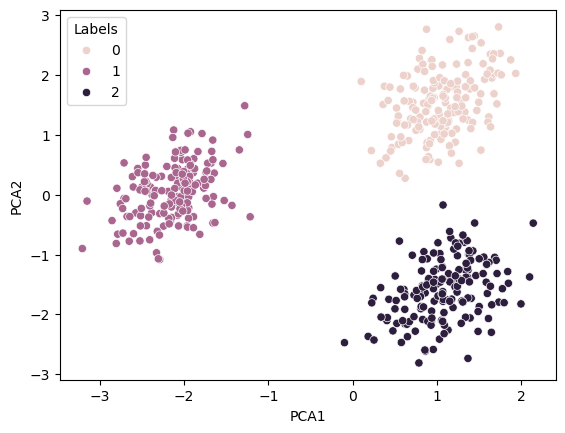

In [23]:
sns.scatterplot( x = "PCA1" , y = "PCA2" , data=df_pca , hue="Labels")